<a href="https://colab.research.google.com/github/KarthikReddyvmd/Ethnotech-Data-Analytics-Training/blob/main/Reggression/Regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [33]:
from google.colab import files
uploaded = files.upload()

Saving 50_Startups.xlsx to 50_Startups.xlsx


In [34]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sb

In [36]:
df = pd.read_excel('50_Startups.xlsx')

In [37]:
print('DataFrame Shape:', df.shape)
print('\nDataFrame Info:')
df.info()

DataFrame Shape: (50, 5)

DataFrame Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 5 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   R&D Spend        50 non-null     float64
 1   Administration   50 non-null     float64
 2   Marketing Spend  50 non-null     float64
 3   State            50 non-null     object 
 4   Profit           50 non-null     float64
dtypes: float64(4), object(1)
memory usage: 2.1+ KB


In [38]:
df.head()

,R&D Spend,Administration,Marketing Spend,State,Profit
0,165349.20,136897.80,471784.10,New York,192261.83
1,162597.70,151377.59,443898.53,California,191792.06
2,153441.51,101145.55,407934.54,Florida,191050.39
3,144372.41,118671.85,383199.62,New York,182901.99
4,142107.34,91391.77,366168.42,Florida,166187.94


In [39]:
df

,R&D Spend,Administration,Marketing Spend,State,Profit
0,165349.20,136897.80,471784.10,New York,192261.83
1,162597.70,151377.59,443898.53,California,191792.06
2,153441.51,101145.55,407934.54,Florida,191050.39
3,144372.41,118671.85,383199.62,New York,182901.99
4,142107.34,91391.77,366168.42,Florida,166187.94
5,131876.90,99814.71,362861.36,New York,156991.12
6,134615.46,147198.87,127716.82,California,156122.51
7,130298.13,145530.06,323876.68,Florida,155752.60
8,120542.52,148718.95,311613.29,New York,152211.77
9,123334.88,108679.17,304981.62,California,149759.96


In [54]:
x = df.iloc[:,:-1].values
y = df.iloc[:, -1].values

One Hot Encoding

In [55]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
ct = ColumnTransformer(transformers=[('encoder', OneHotEncoder(), [3])], remainder='passthrough')
x = np.array(ct.fit_transform(x))

In [57]:
x

array([[0.0, 0.0, 1.0, 165349.2, 136897.8, 471784.1],
       [1.0, 0.0, 0.0, 162597.7, 151377.59, 443898.53],
       [0.0, 1.0, 0.0, 153441.51, 101145.55, 407934.54],
       [0.0, 0.0, 1.0, 144372.41, 118671.85, 383199.62],
       [0.0, 1.0, 0.0, 142107.34, 91391.77, 366168.42],
       [0.0, 0.0, 1.0, 131876.9, 99814.71, 362861.36],
       [1.0, 0.0, 0.0, 134615.46, 147198.87, 127716.82],
       [0.0, 1.0, 0.0, 130298.13, 145530.06, 323876.68],
       [0.0, 0.0, 1.0, 120542.52, 148718.95, 311613.29],
       [1.0, 0.0, 0.0, 123334.88, 108679.17, 304981.62],
       [0.0, 1.0, 0.0, 101913.08, 110594.11, 229160.95],
       [1.0, 0.0, 0.0, 100671.96, 91790.61, 249744.55],
       [0.0, 1.0, 0.0, 93863.75, 127320.38, 249839.44],
       [1.0, 0.0, 0.0, 91992.39, 135495.07, 252664.93],
       [0.0, 1.0, 0.0, 119943.24, 156547.42, 256512.92],
       [0.0, 0.0, 1.0, 114523.61, 122616.84, 261776.23],
       [1.0, 0.0, 0.0, 78013.11, 121597.55, 264346.06],
       [0.0, 0.0, 1.0, 94657.16, 145077.58

In [58]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=0)

In [59]:
# Feature Scaling

In [60]:
from sklearn.preprocessing import StandardScaler
sc = StandardScaler()
x_train = sc.fit_transform(x_train)
x_test = sc.transform(x_test)

In [61]:
#Model Building

In [62]:
y

array([192261.83, 191792.06, 191050.39, 182901.99, 166187.94, 156991.12,
       156122.51, 155752.6 , 152211.77, 149759.96, 146121.95, 144259.4 ,
       141585.52, 134307.35, 132602.65, 129917.04, 126992.93, 125370.37,
       124266.9 , 122776.86, 118474.03, 111313.02, 110352.25, 108733.99,
       108552.04, 107404.34, 105733.54, 105008.31, 103282.38, 101004.64,
        99937.59,  97483.56,  97427.84,  96778.92,  96712.8 ,  96479.51,
        90708.19,  89949.14,  81229.06,  81005.76,  78239.91,  77798.83,
        71498.49,  69758.98,  65200.33,  64926.08,  49490.75,  42559.73,
        35673.41,  14681.4 ])

In [65]:
from sklearn.linear_model import LinearRegression
model = LinearRegression()
model.fit(x_train, y_train)

LinearRegression()

In [66]:
y_pred = model.predict(x_test)

In [64]:
# Plot test vs Predictions

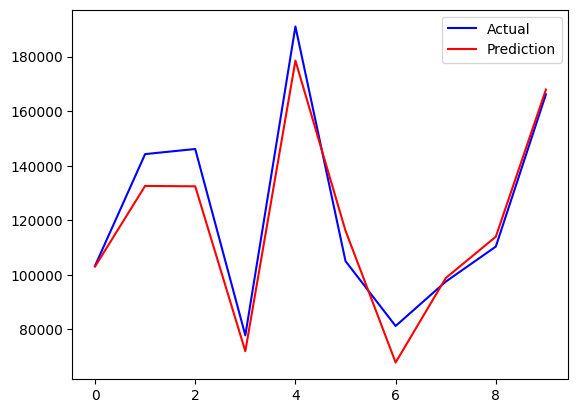

In [67]:
plt.plot(y_test, color='blue' , label='Actual')
plt.plot(y_pred , color = 'red' , label = 'Prediction')
plt.legend()
plt.show()

In [68]:
# Pass the data which is not present in dataset
# New York
# 120k
# 400k
# 120k

In [69]:
df.head(1)

,R&D Spend,Administration,Marketing Spend,State,Profit
0,165349.2,136897.8,471784.1,New York,192261.83


In [70]:
data = [0.0,0.0,1.0,120000,400000,120000]

In [71]:
# Create pandas df

In [72]:
df1 = pd.DataFrame(data)

In [74]:
df1 = sc.transform(df1.T)

In [75]:
# Predictions

In [76]:
single = model.predict(df1)

In [77]:
print(single)

[153616.64191635]


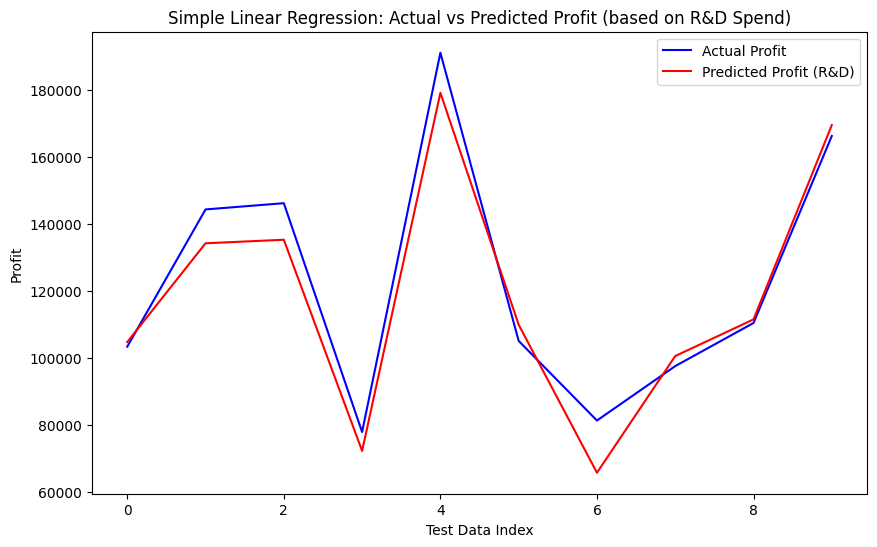

In [79]:
# Keep R & D and try to pred profit .. > Simple Linear Regression

# 1. Prepare data for simple linear regression (R&D Spend vs Profit)
x_simple = df.iloc[:, 0:1].values  # R&D Spend
y_simple = df.iloc[:, -1].values   # Profit

# 2. Split the data
from sklearn.model_selection import train_test_split
x_simple_train, x_simple_test, y_simple_train, y_simple_test = train_test_split(x_simple, y_simple, test_size=0.2, random_state=0)

# 3. Feature Scaling for R&D Spend
from sklearn.preprocessing import StandardScaler
sc_simple = StandardScaler()
x_simple_train = sc_simple.fit_transform(x_simple_train)
x_simple_test = sc_simple.transform(x_simple_test)

# 4. Train Simple Linear Regression Model
from sklearn.linear_model import LinearRegression
model_simple = LinearRegression()
model_simple.fit(x_simple_train, y_simple_train)

# 5. Make predictions
y_simple_pred = model_simple.predict(x_simple_test)

# 6. Plot test vs Predictions for Simple Linear Regression
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 6))
plt.plot(y_simple_test, color='blue', label='Actual Profit')
plt.plot(y_simple_pred, color='red', label='Predicted Profit (R&D)')
plt.title('Simple Linear Regression: Actual vs Predicted Profit (based on R&D Spend)')
plt.xlabel('Test Data Index')
plt.ylabel('Profit')
plt.legend()
plt.show()

In [80]:
x_simple

array([[165349.2 ],
       [162597.7 ],
       [153441.51],
       [144372.41],
       [142107.34],
       [131876.9 ],
       [134615.46],
       [130298.13],
       [120542.52],
       [123334.88],
       [101913.08],
       [100671.96],
       [ 93863.75],
       [ 91992.39],
       [119943.24],
       [114523.61],
       [ 78013.11],
       [ 94657.16],
       [ 91749.16],
       [ 86419.7 ],
       [ 76253.86],
       [ 78389.47],
       [ 73994.56],
       [ 67532.53],
       [ 77044.01],
       [ 64664.71],
       [ 75328.87],
       [ 72107.6 ],
       [ 66051.52],
       [ 65605.48],
       [ 61994.48],
       [ 61136.38],
       [ 63408.86],
       [ 55493.95],
       [ 46426.07],
       [ 46014.02],
       [ 28663.76],
       [ 44069.95],
       [ 20229.59],
       [ 38558.51],
       [ 28754.33],
       [ 27892.92],
       [ 23640.93],
       [ 15505.73],
       [ 22177.74],
       [  1000.23],
       [  1315.46],
       [     0.  ],
       [   542.05],
       [     0.  ]])

In [82]:
y_simple

array([192261.83, 191792.06, 191050.39, 182901.99, 166187.94, 156991.12,
       156122.51, 155752.6 , 152211.77, 149759.96, 146121.95, 144259.4 ,
       141585.52, 134307.35, 132602.65, 129917.04, 126992.93, 125370.37,
       124266.9 , 122776.86, 118474.03, 111313.02, 110352.25, 108733.99,
       108552.04, 107404.34, 105733.54, 105008.31, 103282.38, 101004.64,
        99937.59,  97483.56,  97427.84,  96778.92,  96712.8 ,  96479.51,
        90708.19,  89949.14,  81229.06,  81005.76,  78239.91,  77798.83,
        71498.49,  69758.98,  65200.33,  64926.08,  49490.75,  42559.73,
        35673.41,  14681.4 ])

In [83]:
# Polynomial Regression

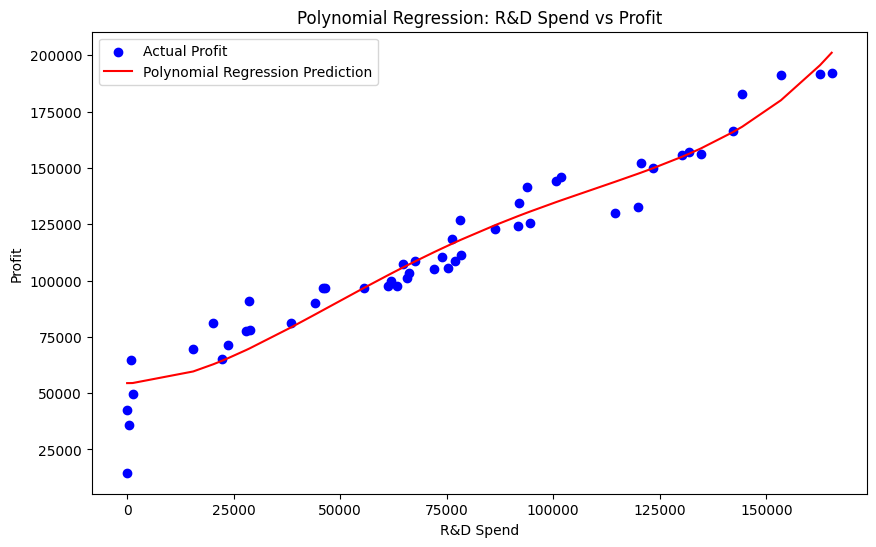

In [85]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
import matplotlib.pyplot as plt

# 1. Create Polynomial Features for R&D Spend (x_simple)
poly_reg = PolynomialFeatures(degree=4) # You can adjust the degree
X_poly = poly_reg.fit_transform(x_simple)

# 2. Train a Linear Regression model on the polynomial features
model_poly = LinearRegression()
model_poly.fit(X_poly, y_simple)

# 3. Make predictions using the polynomial model
y_poly_pred = model_poly.predict(X_poly)

# 4. Visualize the results for Polynomial Regression
plt.figure(figsize=(10, 6))
plt.scatter(x_simple, y_simple, color='blue', label='Actual Profit')
plt.plot(x_simple[x_simple[:,0].argsort()], y_poly_pred[x_simple[:,0].argsort()], color='red', label='Polynomial Regression Prediction')
plt.title('Polynomial Regression: R&D Spend vs Profit')
plt.xlabel('R&D Spend')
plt.ylabel('Profit')
plt.legend()
plt.show()